# 📝 Previous Sessions Analysis

As teams prepare for the upcoming race, they use the most recent data collected through the weekend to try to come up with race strategies and plans. Let's take a look...

## 📊 How to evaluate performance?

Most of the teams are not on top of the grid. They fall somewhere along the midfield pack. How do these teams evaluate their performance when they are not able to beat the top teams?

Furthermore, practice sessions do not have positions. So how do we evaluate performance when positions are not taken into consideration?

Most of the time, teams evaluate their pace, that is, their lap time. Achieving good lap times is the fundamental way to win a race, even though good lap times are not everything. For this specific grand prix, the correlation between lap times and position are about 0.80 of 1.

To achieve this, we will use FastF1s `pick_quicklaps` method as it filters **only laps within 107% of the fastest lap of the session**, excluding non-push laps from the analysis.

## ⚙️ Environment setup

In [ ]:
import os

import fastf1 as ff1
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from fastf1 import plotting
from fastf1.logger import set_log_level

from plots.laps import plot_laptime_correlation_heatmap, plot_team_vs_grid_tyre_wear
from plots.tyres import (
    plot_average_lap_time_by_tyre_wear,
    plot_laptime_distribution_by_team_with_tyre_life,
    plot_tyre_decay_scatter_plot,
)
from processing.laps import get_tyre_life_stats
from tests.comparisons import compare_team_series_to_overall_series
from tests.distribution import ks_test, mann_whitney_u_test
from tests.normality import plot_normality_visual_inspection, shapiro_wilk_test

load_dotenv()

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")
np.random.seed(123)  # noqa: NPY002

TEAM = os.getenv("TEAM")
EVENT_YEAR = int(os.getenv("EVENT_YEAR"))
ROUND = int(os.getenv("ROUND"))

%matplotlib widget

## 📚 Aggregating and cleaning data

### 🗂️ Aggregating laps data from all previous sessions in the weekend

We will use data from all the other sessions and aggregate them into a single DataFrame.

In [2]:
fp1 = ff1.get_session(EVENT_YEAR, ROUND, "FP1")
sq = ff1.get_session(EVENT_YEAR, ROUND, "SQ")
sprint = ff1.get_session(EVENT_YEAR, ROUND, "S")
quali = ff1.get_session(EVENT_YEAR, ROUND, "Q")
fp1.load()
sq.load()
sprint.load()
quali.load()

In [3]:
fp1_push_laps = fp1.laps.pick_quicklaps()
sq_push_laps = sq.laps.pick_quicklaps()
sprint_push_laps = sprint.laps.pick_quicklaps()
quali_push_laps = quali.laps.pick_quicklaps()

In [4]:
all_laps = pd.concat(
    [
        fp1_push_laps.assign(Session="FP1"),
        sq_push_laps.assign(Session="SQ"),
        sprint_push_laps.assign(Session="Sprint"),
        quali_push_laps.assign(Session="Quali"),
    ],
    ignore_index=True,
)

### ✨ Cleaning data and feature engineering

In [5]:
all_laps = all_laps[~all_laps["Deleted"]]  # Removing deleted laps, they are invalid

Converting lap times to seconds is very important to allow better calculations.

In [6]:
all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()

C:\Users\Vitor\AppData\Local\Temp\ipykernel_28896\2692686783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()


In [7]:
# Removing unused featured for easier and lighter calculations
DROP_FEATURES = [
    "Deleted",
    "DeletedReason",
    "FastF1Generated",
    "LapStartTime",
    "LapStartDate",
    "Sector1SessionTime",
    "Sector2SessionTime",
    "Sector3SessionTime",
    "IsPersonalBest",
    "IsAccurate",
    "SpeedFL",
]
all_laps = all_laps.drop(columns=DROP_FEATURES)

Converting these data to integers is important to calculate correlations.

In [8]:
session_dummies = pd.get_dummies(all_laps.Session, prefix="Session", dtype=int)
all_laps = pd.concat([all_laps, session_dummies], axis=1)

### 🏷️ Separating data between different tyre compounds

In [9]:
soft = all_laps.pick_compounds("SOFT")
medium = all_laps.pick_compounds("MEDIUM")
hard = all_laps.pick_compounds("HARD")

## 🕰️ Analyzing lap time trends and distribution

### ⏳ Analyzing general lap time

Firstly, let's take a look at how much time a lap time takes, taking into consideration all of the grid, regardless of session or tyre compound.

In [10]:
print(
    f"An average lap takes {all_laps.LapTime_s.mean():.3f} "
    f" +/- {all_laps.LapTime_s.std():.3f}",
)

An average lap takes 84.157  +/- 2.182


Therefore, mere seconds each lap can determine winners and loses.

Test stastic 0.9068
P-Value 0.0000
The data does NOT look normally distributed.


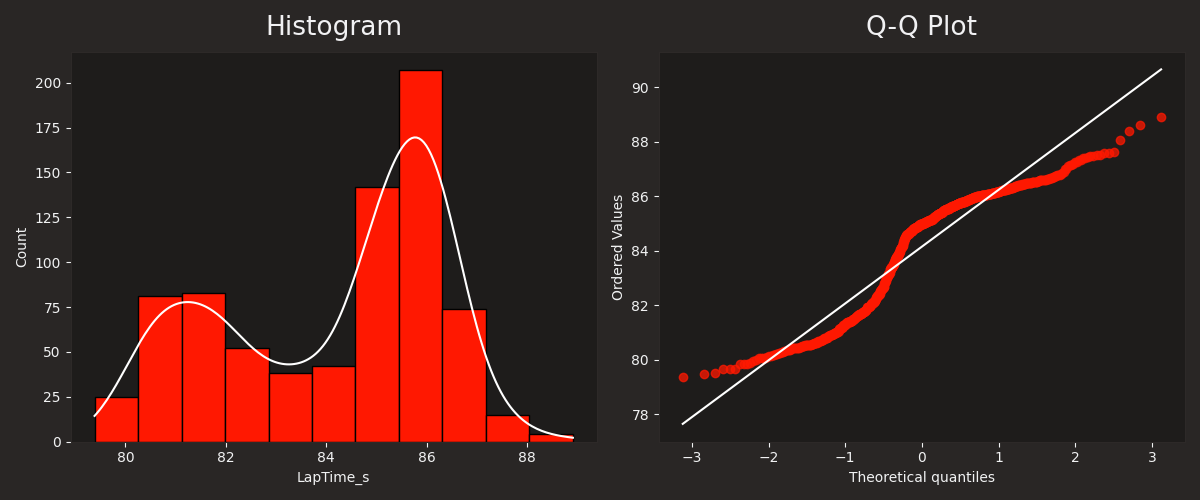

In [11]:
shapiro_wilk_test(all_laps.LapTime_s)
plot_normality_visual_inspection(all_laps.LapTime_s)

Notice how the data is not normally distributed. This is very common in motorsports, as the cars usually drive very near to the physical limits. We will have to use non-parametric statistical tests when analyzing lap times.

Check how the results change for different tyre compounds:

Test stastic 0.8181
P-Value 0.0000
The data does NOT look normally distributed.


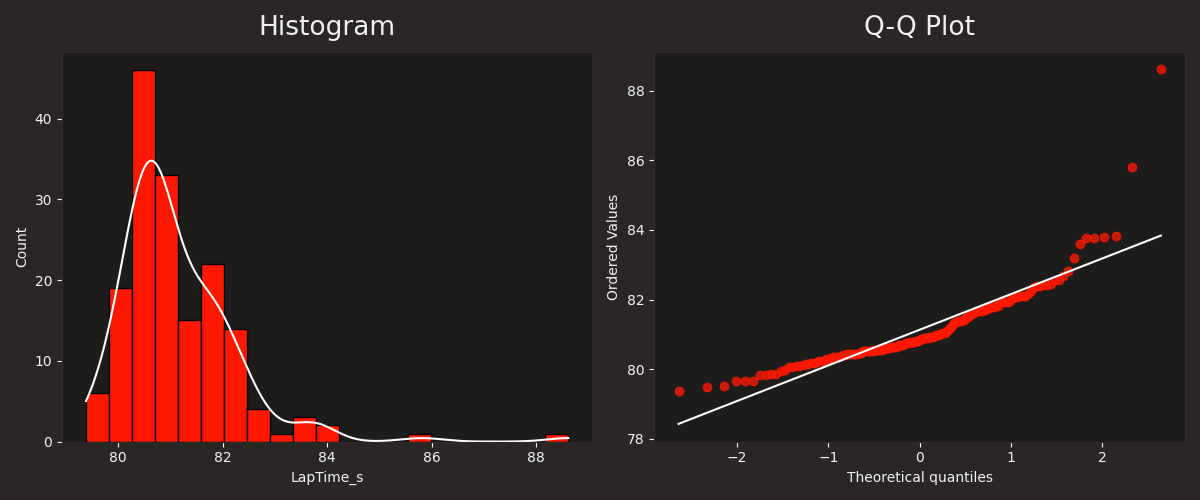

In [12]:
shapiro_wilk_test(soft.LapTime_s)
plot_normality_visual_inspection(soft.LapTime_s)

This heavy concentration on the left could be explained by the fact that soft tyres are the ones that bring the cars nearest to the physical limits of speeds for which they have been designed. These are used mainly for short stints, such as qualifying laps. We will further delve into this later.

Test stastic 0.8705
P-Value 0.0000
The data does NOT look normally distributed.


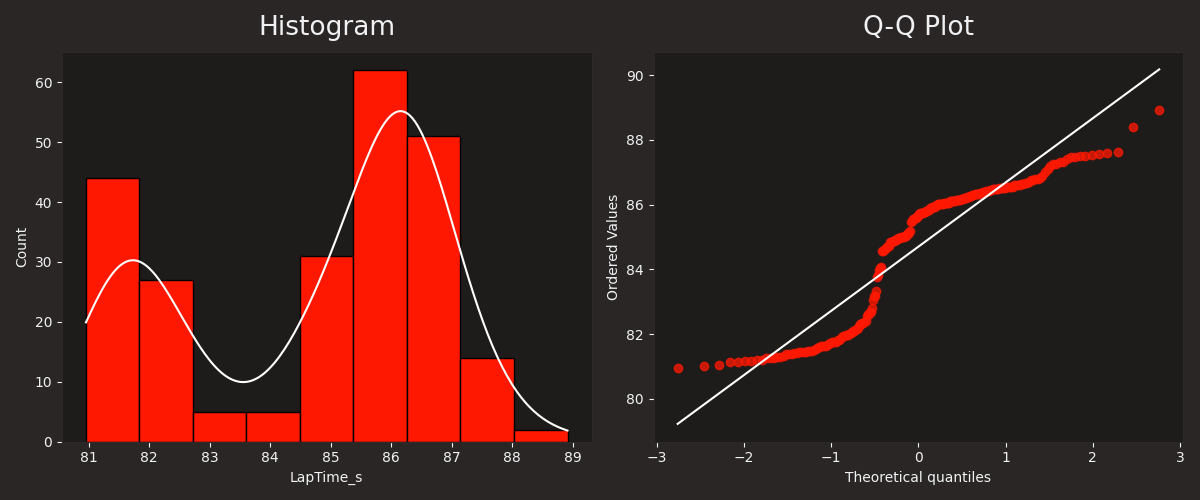

In [13]:
shapiro_wilk_test(medium.LapTime_s)
plot_normality_visual_inspection(medium.LapTime_s)

Interestingly, there seems to be two different concentrations for medium tires. We will delve deeper into this later.

Test stastic 0.9458
P-Value 0.0000
The data does NOT look normally distributed.


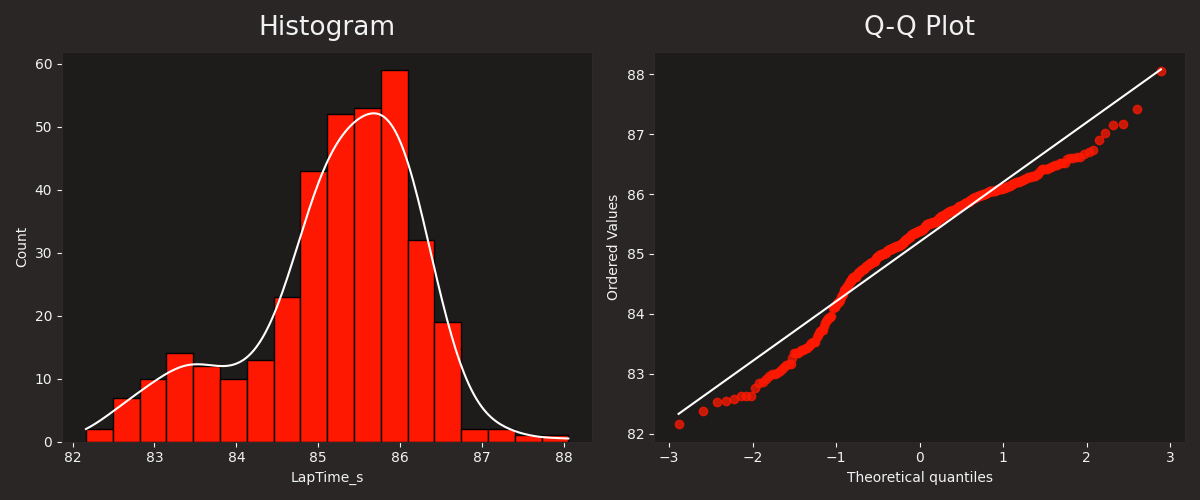

In [14]:
shapiro_wilk_test(hard.LapTime_s)
plot_normality_visual_inspection(hard.LapTime_s)

However, for hard tyres, while the test still fails, the curve is much more bell-shaped than the others. We will also delve deeper for these.

### ⚡ Analyzing general lap time by speeds registered (Intermediate 1)

As will be further explained in this notebook, the speed from the first intermediate in this circuit is decisive to establish good lap times. It is the most important part of the circuit for reducing lap times.

Test stastic 0.9466
P-Value 0.0000
The data does NOT look normally distributed.


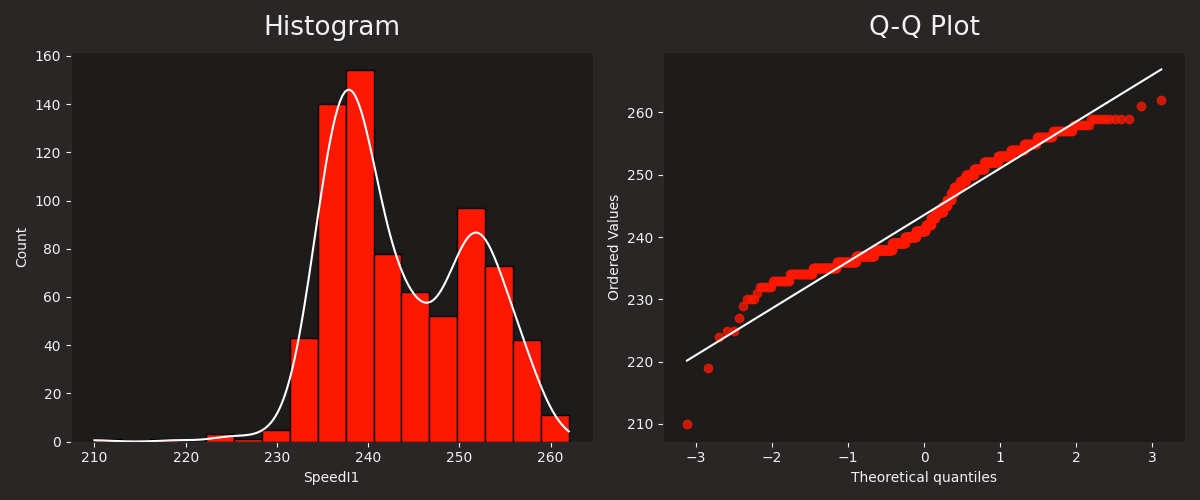

In [15]:
shapiro_wilk_test(all_laps["SpeedI1"])
plot_normality_visual_inspection(all_laps["SpeedI1"])

The curves here seem to inversely replicate the trends for the curves of the lap times, logically, as higher speeds result in faster lap times.

#### 📈 Are these actually the same distributions?

To validate whether these distributions are actually the same, but mirrored, we will do a quick standardization and flipping of the data.

All Tyre Types

========== Mann-Whitney U test ==========
Test statistic 289325.5000
P-Value 0.8381
There IS a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.3696
P-Value: 0.0000
The distributions are statistically DIFFERENT


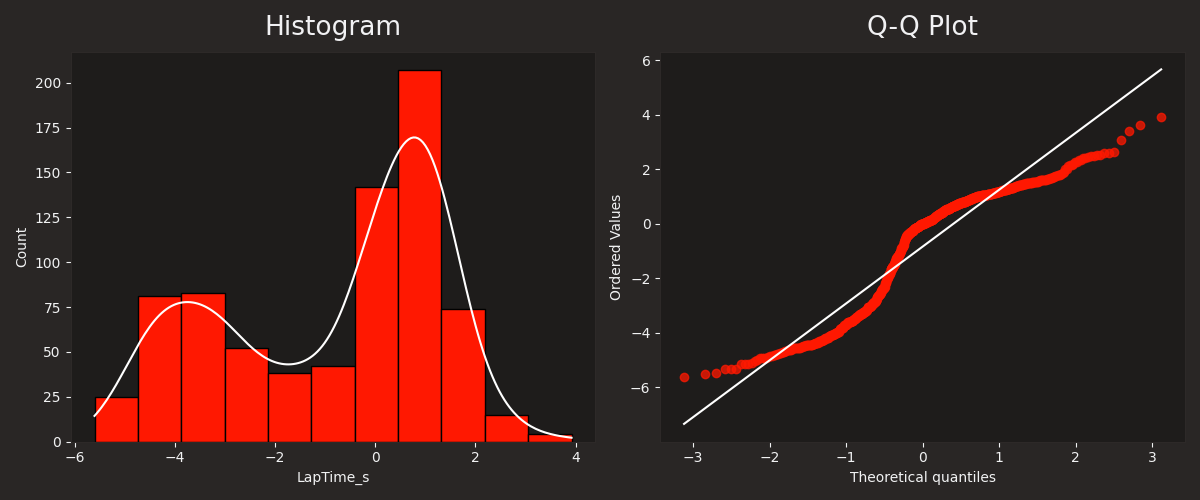

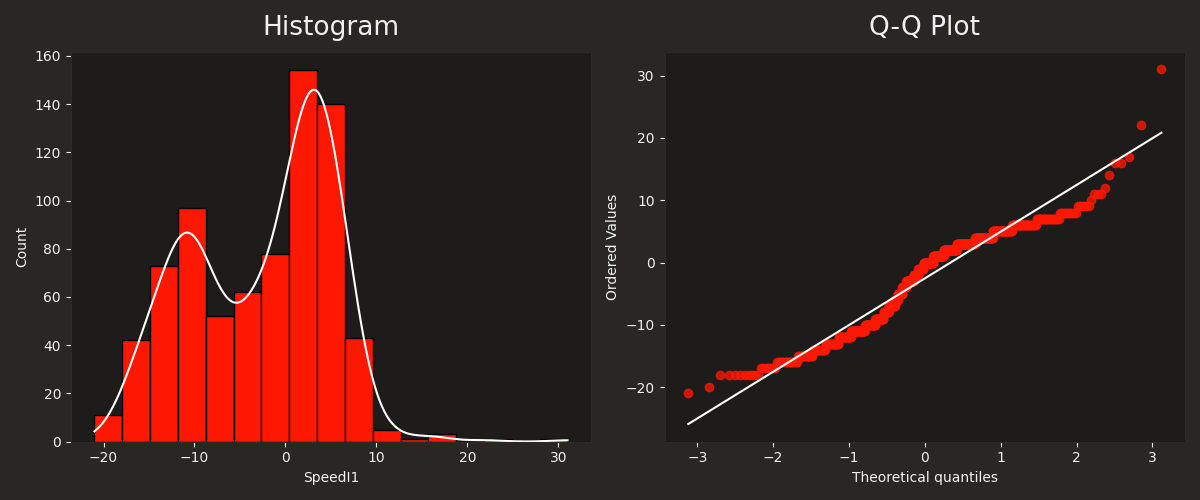

SOFT

========== Mann-Whitney U test ==========
Test statistic 14129.0000
P-Value 0.8347
There IS a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.3653
P-Value: 0.0000
The distributions are statistically DIFFERENT


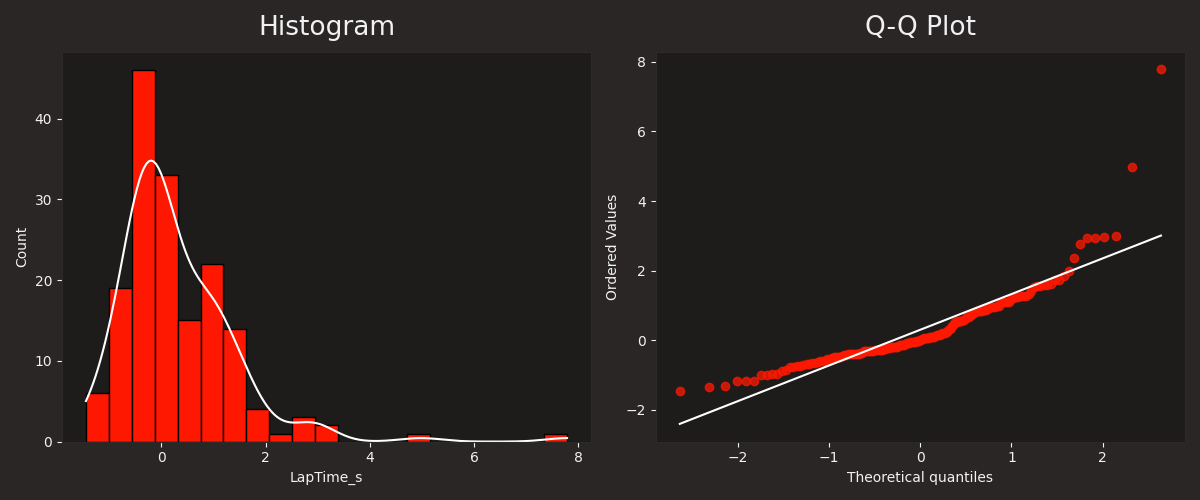

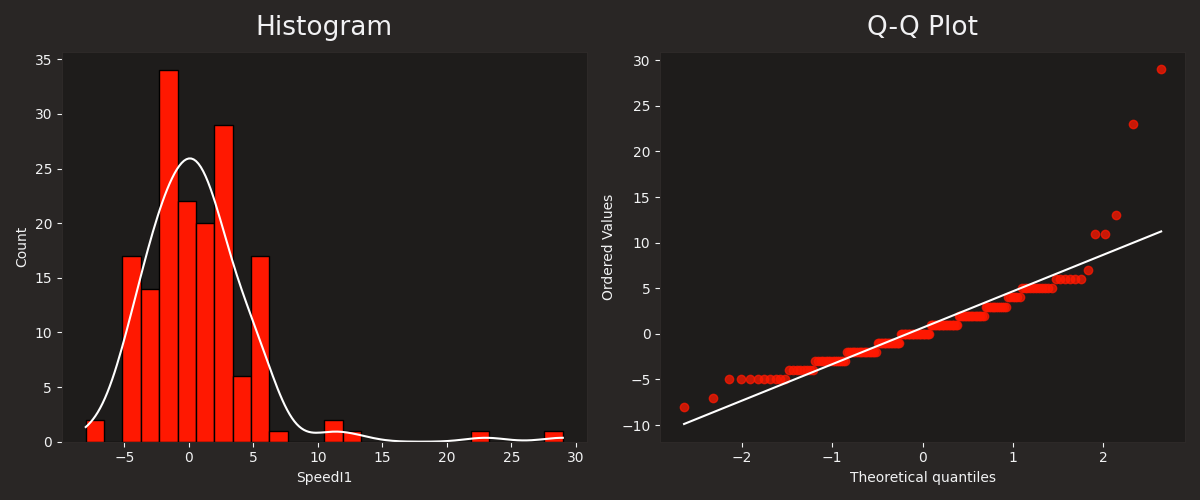

MEDIUM

========== Mann-Whitney U test ==========
Test statistic 29471.5000
P-Value 0.7782
There IS a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.3610
P-Value: 0.0000
The distributions are statistically DIFFERENT


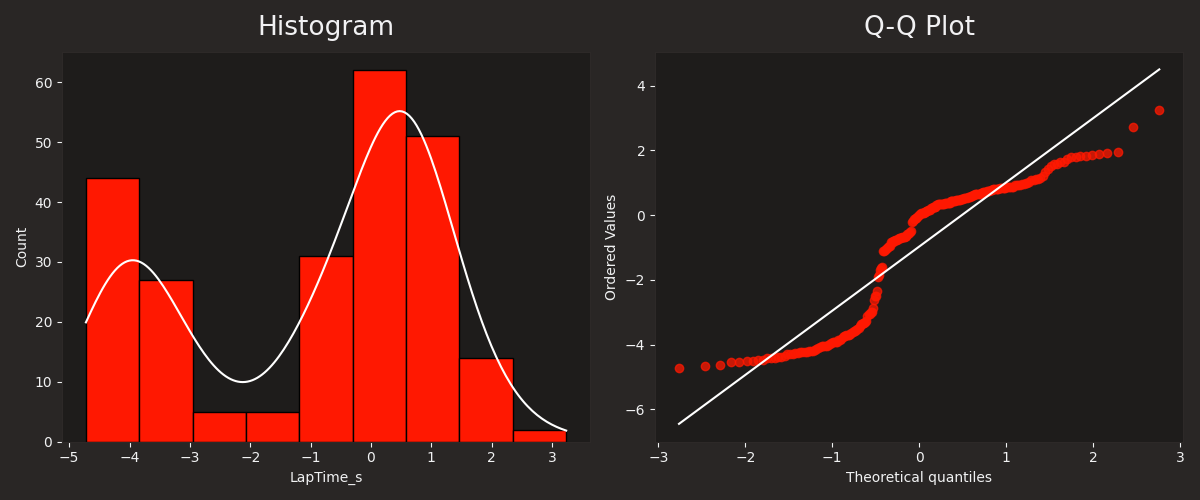

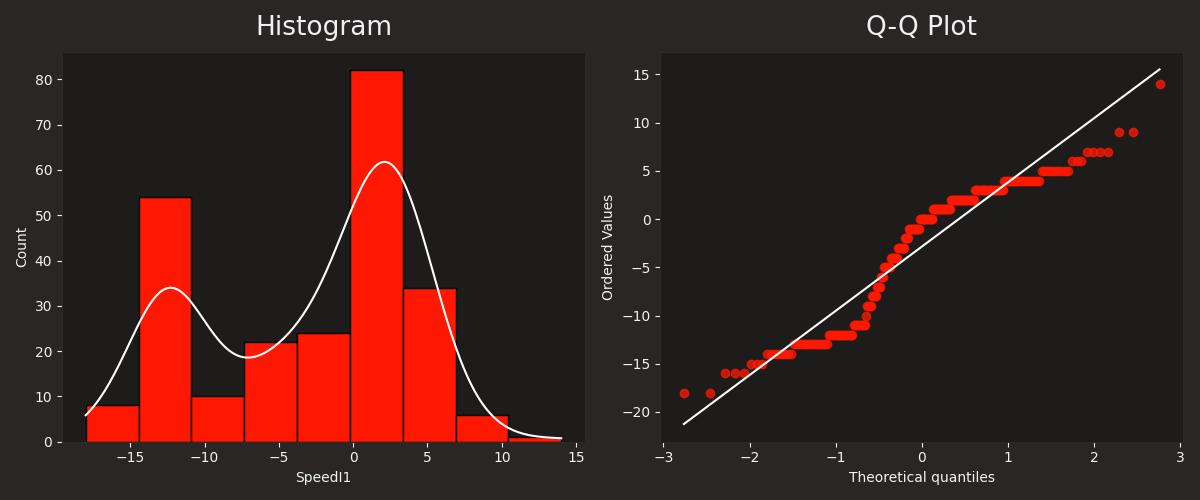

HARD

========== Mann-Whitney U test ==========
Test statistic 59813.0000
P-Value 0.2416
There IS a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.3380
P-Value: 0.0000
The distributions are statistically DIFFERENT


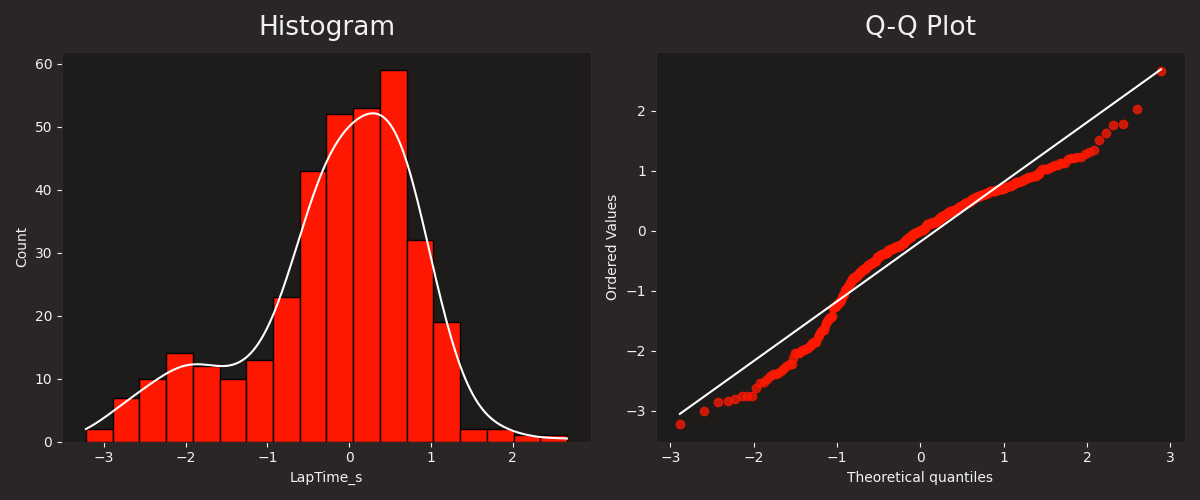

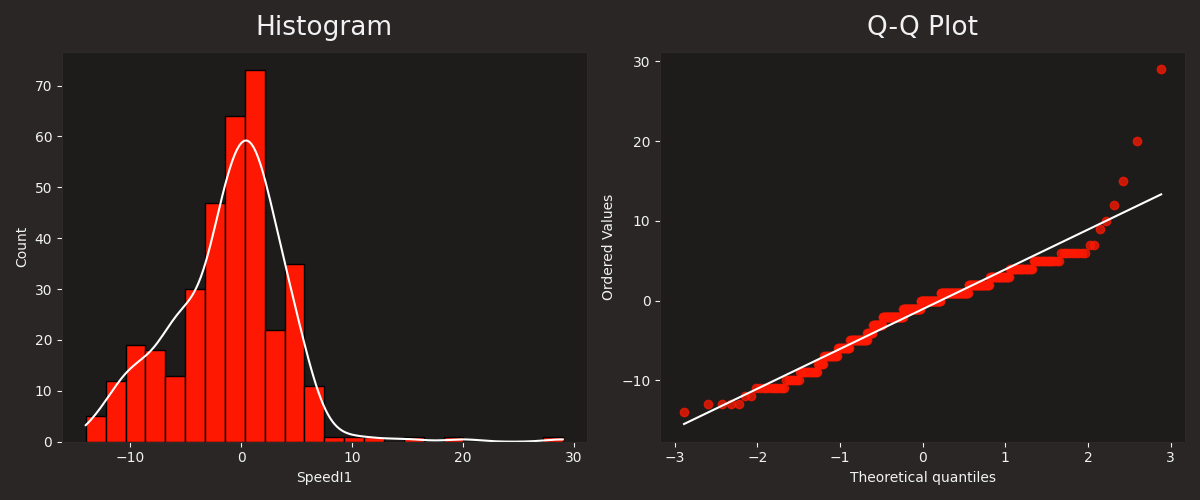

In [16]:
TYRES_CONFIG = ["All Tyre Types", "SOFT", "MEDIUM", "HARD"]

for tyre_config, laps_data in zip(
    TYRES_CONFIG,
    [all_laps, soft, medium, hard],
    strict=False,
):
    print(tyre_config)

    speed_centered = laps_data.SpeedI1 - np.median(laps_data.SpeedI1)
    laptime_centered = laps_data.LapTime_s - np.median(laps_data.LapTime_s)

    speed_mirrored = -speed_centered

    print()
    mann_whitney_u_test(speed_mirrored, laptime_centered)
    print()
    ks_test(speed_mirrored, laptime_centered)
    plot_normality_visual_inspection(laptime_centered)
    plot_normality_visual_inspection(speed_mirrored)

Though there is statistically significant difference between the distributions, the trends still look very similar and these are highly correlated values.

## 🛞 Analyzing Tyres

Tyre management is one of the most crucial areas for having success in Formula 1. As will be further explained, in this specific grand prix, it was a big part of the final positions.

As drivers complete laps, the amount of tyre wear increases, causing the tyre to lose performance and increase lap time. However, cold tyres also do not offer good grip, which is crucial for achieving good cornering speeds.

Therefore, most compounds have an optimal window of performance, balancing temperature and tyre wear.

### 🟡 Analyzing Medium Tyre Compound influence on Lap Time

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


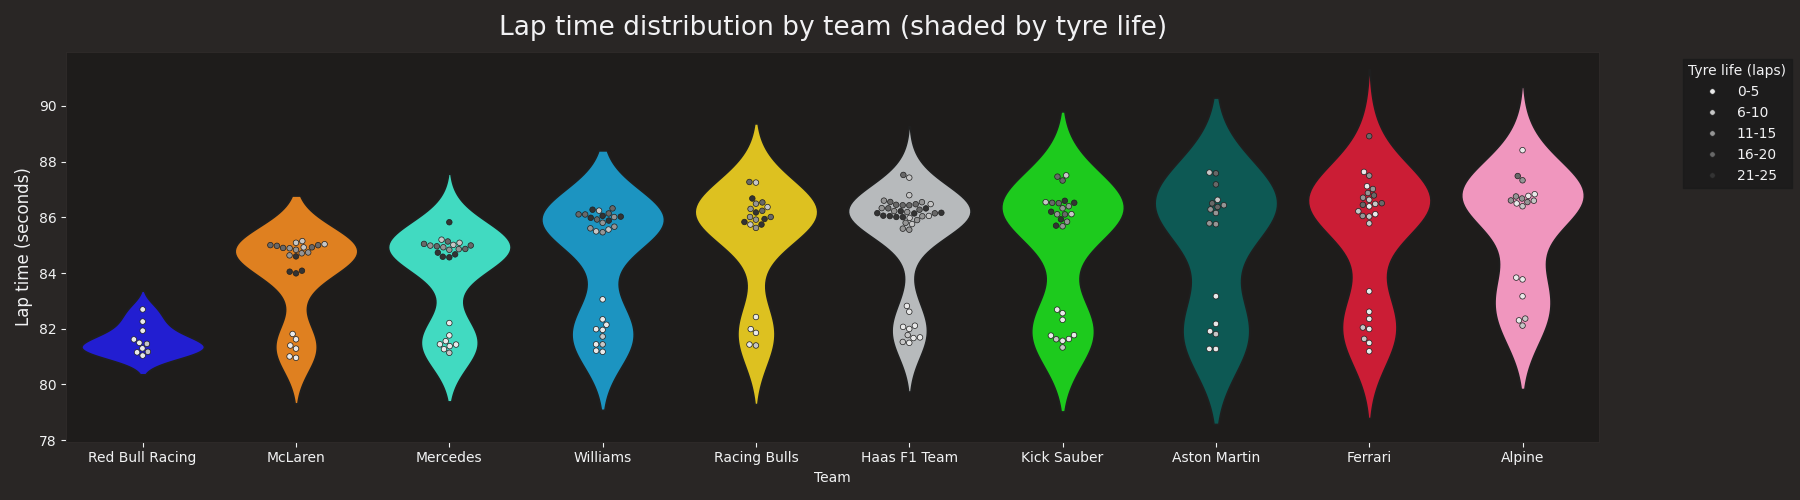

In [52]:
plot_laptime_distribution_by_team_with_tyre_life(medium, quali)

It is possible to notice that most teams follow similar distributions for Medium Tyres. Keep in mind, however, that this is not a perfect comparison of lap times for a race since the data aggregates all types of sessions.

In [ ]:
compare_team_series_to_overall_series(mann_whitney_u_test, medium, TEAM, "LapTime_s")

Comparing against Red Bull Racing
========== Mann-Whitney U test ==========
Test statistic 288.0000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Kick Sauber
========== Mann-Whitney U test ==========
Test statistic 288.0000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Racing Bulls
========== Mann-Whitney U test ==========
Test statistic 288.0000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Alpine
========== Mann-Whitney U test ==========
Test statistic 288.0000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Mercedes
========== Mann-Whitney U test ==========
Test statistic 288.0000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Aston Martin
========== Mann-Whitney U test ==========
Test statistic 288.0000
P-Valu

This test is highly insensitive to variance, focusing in shifts in locations (medians or means). Therefore, it highlights how complex trying to analyze F1 can be: even between the fastest and the slowest teams on the grid, according to the Mann-Whitney U test, it still is not possible to detect a difference between the lap time that is statistically significant regarding to measures of central tendency.

Notably, however, there is an excpetion for team #3.

In [ ]:
compare_team_series_to_overall_series(ks_test, medium, TEAM, "LapTime_s")

Comparing against Red Bull Racing
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Kick Sauber
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Racing Bulls
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Alpine
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Mercedes
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Aston Martin
========== Kolomogorov-Smir

However, when testing using Kolmogorov-Smirnov, it was possible to identify differences between most of the grid, with the notable exception of team 3. This tests focuses on extracting the maximum vertical distance between two cumulative curves, evaluating overall goodness-of-fit. It is more sensitive to shifts in variance or overall shape. Therefore, the main statistically significant difference between teams' laps in this weekend lies on consistency rather than mean or median pace. Keep this in mind as we analyze the race results!

#### 🟡 How do these tyres influence on lap time and speed?

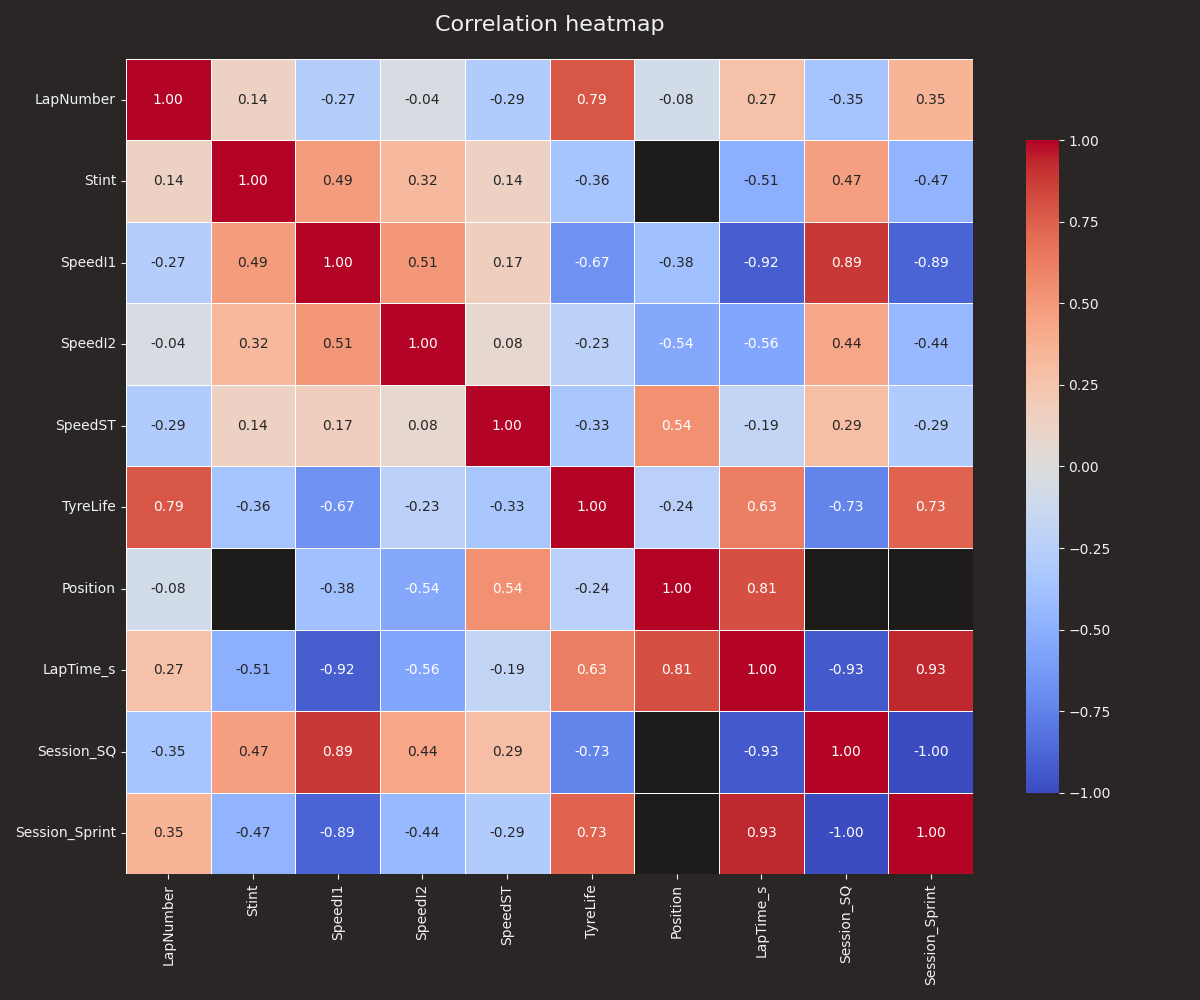


--- Correlations with LapTime_s ---
Session_SQ        -0.93
Session_Sprint     0.93
SpeedI1           -0.92
Position           0.81
TyreLife           0.63
SpeedI2           -0.56
Stint             -0.51
LapNumber          0.27
SpeedST           -0.19
Name: LapTime_s, dtype: object


In [21]:
plot_laptime_correlation_heatmap(medium)

While analyzing the factors with most influence of lap time when using medium tyres, it was possible to detect the highest correlations to be associated with the session type, highlighting how different laps can be in different sessions.

Speed through the first intermediate of the track was the most decisive feature to extract good lap times. This speed is highly correlated to the medium tyres wear (TyreLife) with a value of -0.67. This is expected, as tyre grip is one of the crucial components to achieve higher cornering speeds.

As expected, there is a high correlation between lap time and position (0.81).

Finally, tyre life shows up as a direct correlation to the lap time (0.63) when using medium tyres.

 These data are crucial to design a race plan and where to focus on the track.

#### 🟡 Medium Tyre Performance Decay

Now, let's use the data to understand tyre performance decay. This can be crucial to determine pit stops and overall race strategy.

When analyzing tyre performance, it is crucial, as we have seen before, to separate between sessions and focus more on the trend for the lap time delta as laps increase rather than the raw output of time, since different sessions tend to have lower lap times (qualifying).

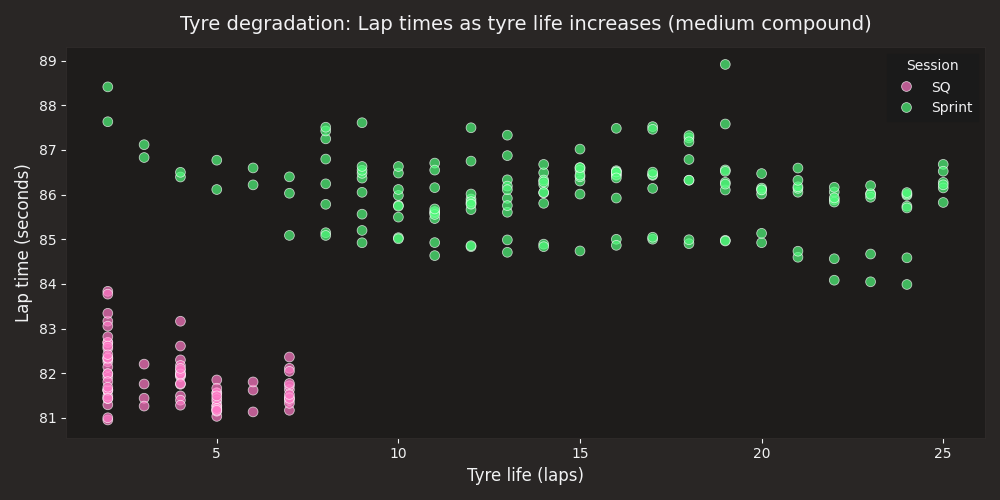

In [22]:
plot_tyre_decay_scatter_plot(medium)

In [23]:
mann_whitney_u_test(
    medium[medium.Session_SQ == 1]["LapTime_s"],
    medium[medium.Session_Sprint == 1]["LapTime_s"],
)
print()
ks_test(
    medium[medium.Session_SQ == 1]["LapTime_s"],
    medium[medium.Session_Sprint == 1]["LapTime_s"],
)

========== Mann-Whitney U test ==========
Test statistic 0.0000
P-Value 0.0000
There is NOT a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
The distributions are statistically DIFFERENT


(np.float64(1.0), np.float64(4.630625161998186e-65))

While, once again, central locations are very similar between the two types of session, while the distributions shapes and variance are statistically different for lap times.

Having a sprint session is very useful, as, while shorter, it is a de facto race! Let's try to use mostly sprint session data to see just by how much lap time changes according to tyre wear.

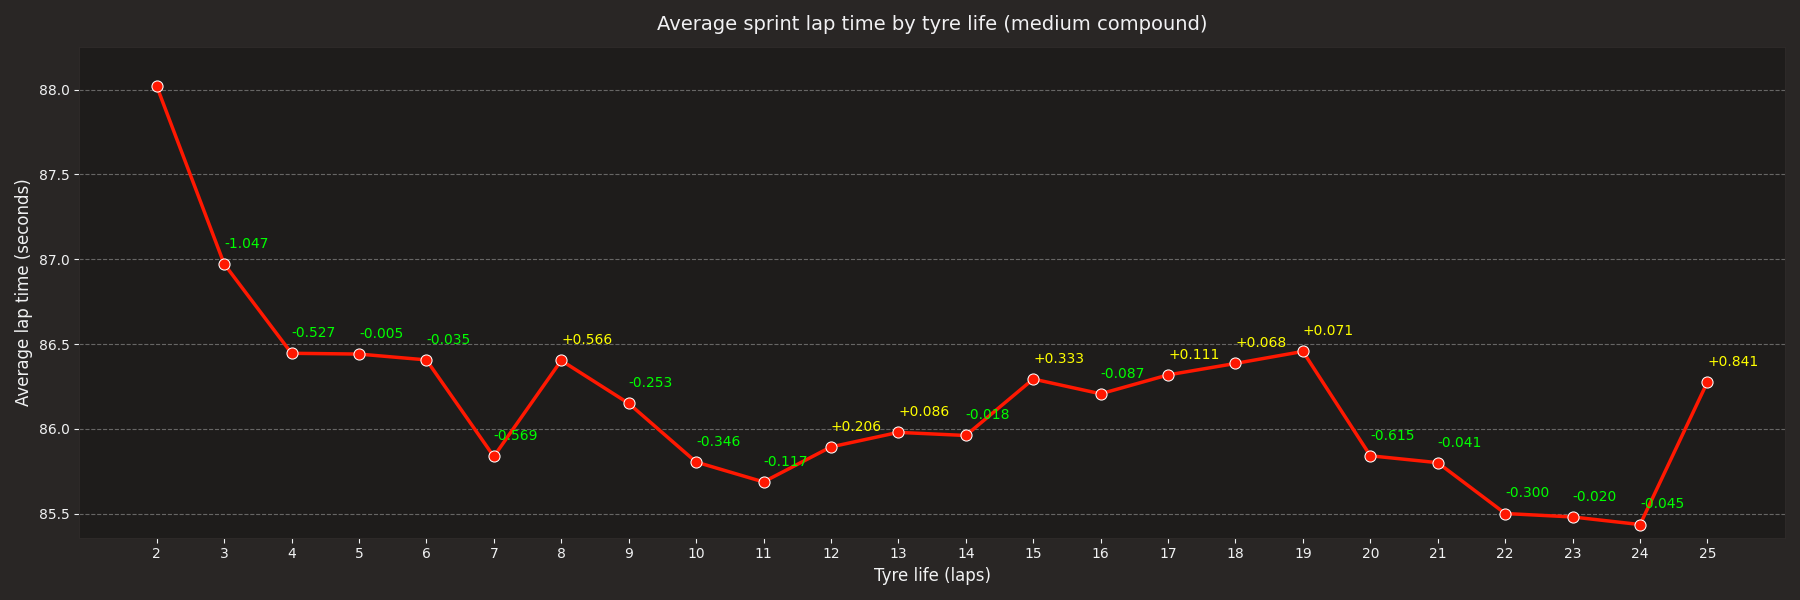

In [24]:
mean_laps_by_life_medium = get_tyre_life_stats(medium, session="Sprint")
plot_average_lap_time_by_tyre_wear(mean_laps_by_life_medium, "Medium", sprint)

Therefore, the data seems to indicate that the optimal performance window for medium tyres lies between 8 to 15 laps, then there is a drop in time near the end of the usage limit (25).

Let's now take a look at how the performance decay looks like for our team.

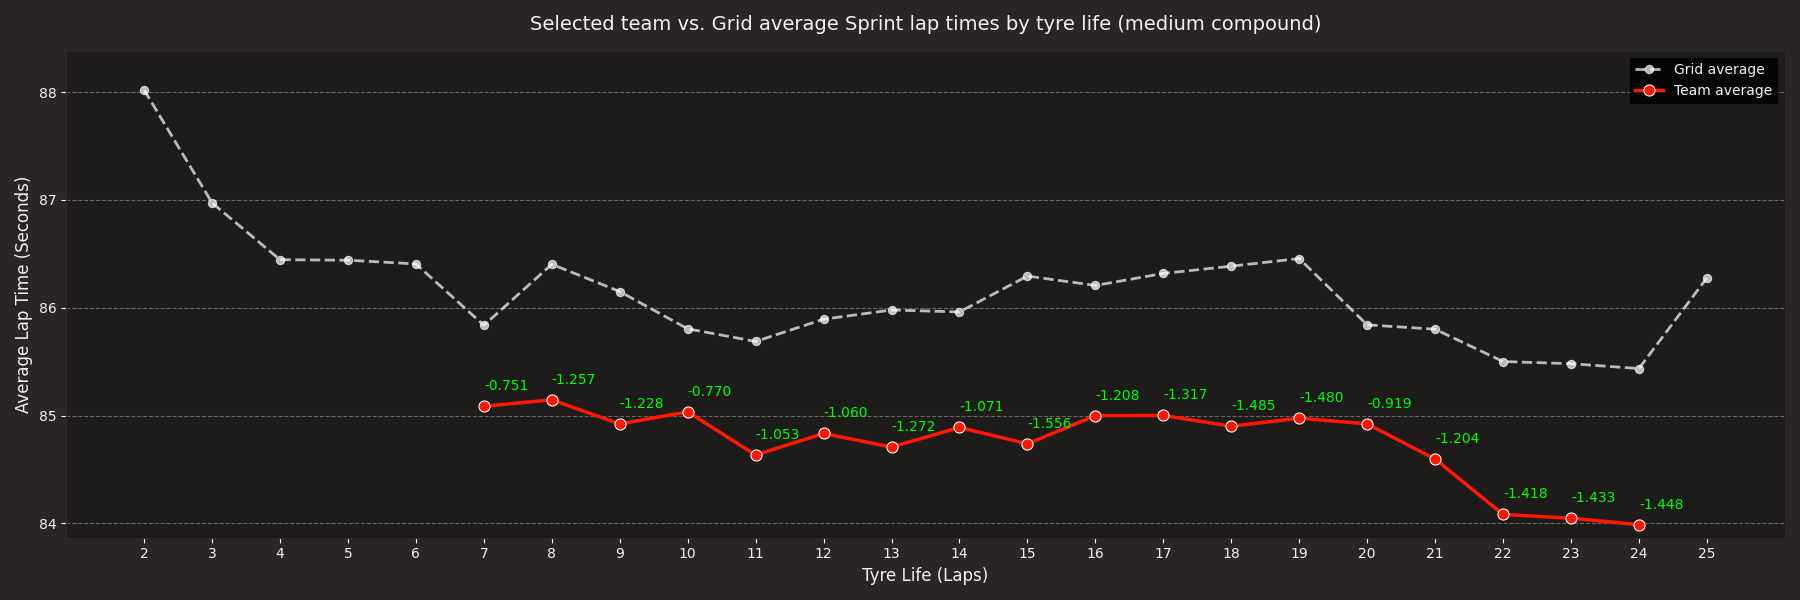

In [ ]:
team_mean_laps_by_life_medium = get_tyre_life_stats(
    medium.pick_teams(TEAM),
    session="Sprint",
)
plot_team_vs_grid_tyre_wear(
    mean_laps_by_life_medium,
    team_mean_laps_by_life_medium,
    "MEDIUM",
    "Sprint",
)

In [26]:
print(
    f"Overall average lap time: {mean_laps_by_life_medium.LapTime_s.mean():.3f} "
    f"+/- {mean_laps_by_life_medium.LapTime_s.std():.3f}",
)

Overall average lap time: 86.167 +/- 0.545


In [27]:
print(
    f"Our team's average lap time: {team_mean_laps_by_life_medium.LapTime_s.mean():.3f} "
    f" +/- {team_mean_laps_by_life_medium.LapTime_s.std():.3f}",
)

Our team's average lap time: 84.751  +/- 0.359


Not only the average lap time is lower, but the standard deviation is also lower, establishing consistency. Also, from the graph, it is possible to see less dramatic spikes in lap time. But the tests still bring the same results:

In [28]:
mann_whitney_u_test(
    mean_laps_by_life_medium.LapTime_s,
    team_mean_laps_by_life_medium.LapTime_s,
)
print()
ks_test(mean_laps_by_life_medium.LapTime_s, team_mean_laps_by_life_medium.LapTime_s)

========== Mann-Whitney U test ==========
Test statistic 432.0000
P-Value 0.0000
There is NOT a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
The distributions are statistically DIFFERENT


(np.float64(1.0), np.float64(5.6545554966993126e-12))

### ⚪ Analyzing Hard Tyre Compound influence on LapTime

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


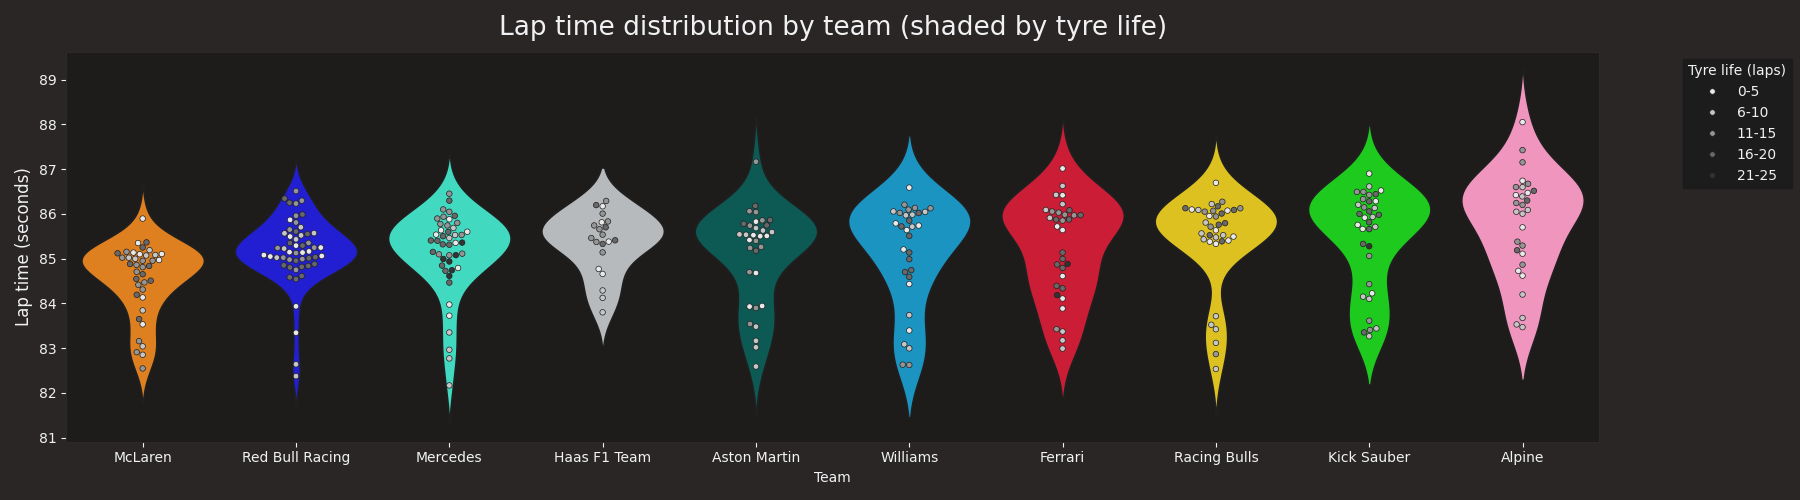

In [30]:
plot_laptime_distribution_by_team_with_tyre_life(hard, quali)

While the graph for medium tyres had concentrations on both lower lap times with less tyre wear as higher lap times with high tyre wear, the concentrations for hard tyres are mostly on higher lap times with high tyre life.

In [ ]:
compare_team_series_to_overall_series(mann_whitney_u_test, hard, TEAM, "LapTime_s")

Comparing against Red Bull Racing
========== Mann-Whitney U test ==========
Test statistic 760.5000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Kick Sauber
========== Mann-Whitney U test ==========
Test statistic 760.5000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Racing Bulls
========== Mann-Whitney U test ==========
Test statistic 760.5000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Alpine
========== Mann-Whitney U test ==========
Test statistic 760.5000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Mercedes
========== Mann-Whitney U test ==========
Test statistic 760.5000
P-Value 1.0000
There IS a statistically significant difference between the series.

Comparing against Aston Martin
========== Mann-Whitney U test ==========
Test statistic 760.5000
P-Valu

In [ ]:
compare_team_series_to_overall_series(ks_test, hard, TEAM, "LapTime_s")

Comparing against Red Bull Racing
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Kick Sauber
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Racing Bulls
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Alpine
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Mercedes
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Aston Martin
========== Kolomogorov-Smir

Curiously, our team's lap times seem to follow the same distribution shape as other teams, however, with a lower lap time when measuring central locations.

#### ⚪ How do these tyres influence on lap time?

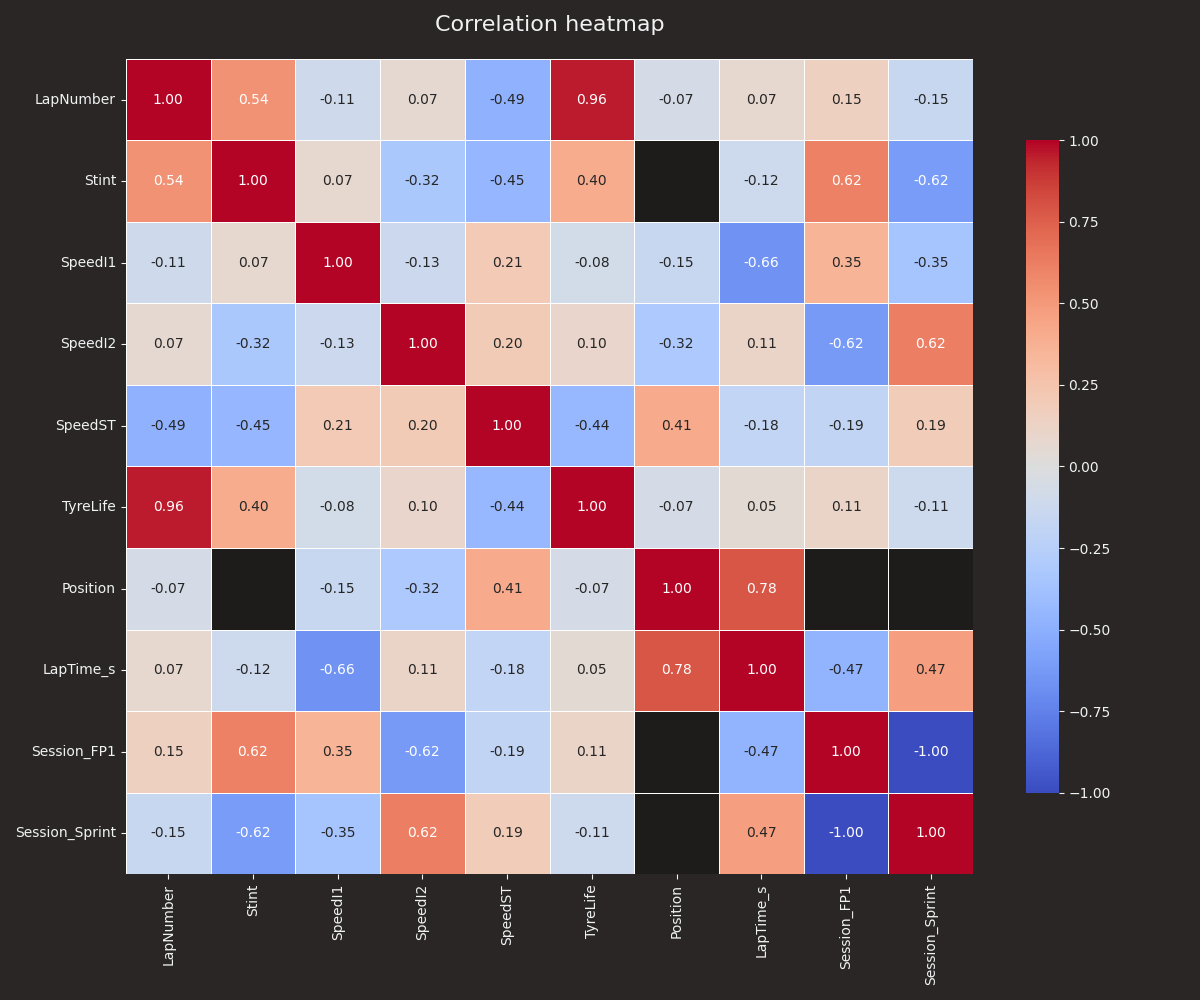


--- Correlations with LapTime_s ---
Position           0.78
SpeedI1           -0.66
Session_FP1       -0.47
Session_Sprint     0.47
SpeedST           -0.18
Stint             -0.12
SpeedI2            0.11
LapNumber          0.07
TyreLife           0.05
Name: LapTime_s, dtype: object


In [33]:
plot_laptime_correlation_heatmap(hard)

Once again, speed through intermediate 1 is still important, though not as much as for medium tyres. Tyre life on hard tyres seem to have no correlation with speed through the first intermediate. There is a negative correlation with speed on the straights (-0.44), however, speed on the straights is not as important as SpeedI1 (-0.18 vs -0.66) for lap times.

There is no indication of direct correlation between tyre life and lap times for hard tyres, but speed on the straights is still a relevant metric to consider while analyzing overtaking opportunities on different circuits. So this has to be kept in mind when developing race strategies.

#### ⚪ Analyzing Hard Tyre Compound performance decay

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:80: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 5))


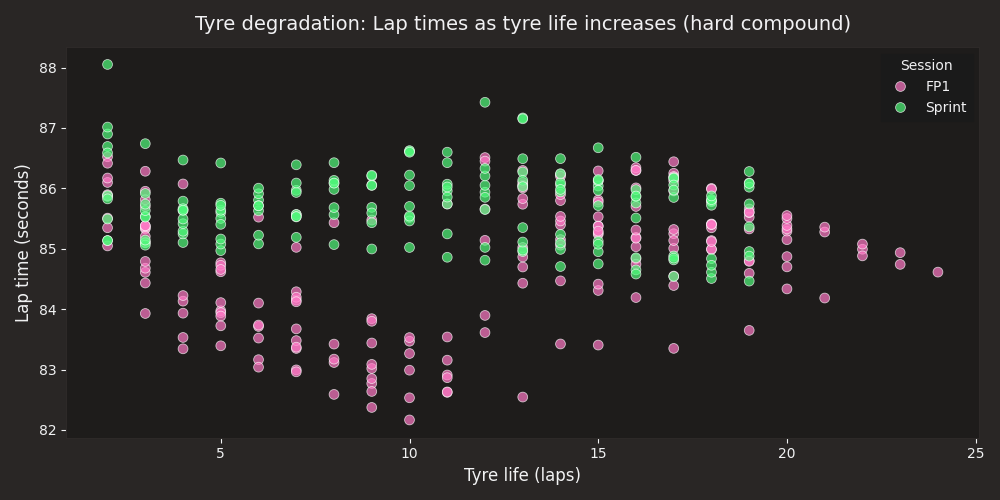

In [34]:
plot_tyre_decay_scatter_plot(hard)

Once again,the graph seems to be vertically separated between sessions.

In [35]:
mann_whitney_u_test(
    hard[hard.Session_FP1 == 1]["LapTime_s"],
    hard[hard.Session_Sprint == 1]["LapTime_s"],
)
print()
ks_test(
    hard[hard.Session_FP1 == 1]["LapTime_s"],
    hard[hard.Session_Sprint == 1]["LapTime_s"],
)

========== Mann-Whitney U test ==========
Test statistic 7686.0000
P-Value 0.0000
There is NOT a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.4083
P-Value: 0.0000
The distributions are statistically DIFFERENT


(np.float64(0.4082934609250399), np.float64(1.0332382975397134e-13))

As for medium tyres, central locations are very similar between the two types of session, while the distributions shapes and variance are statistically different for lap times.

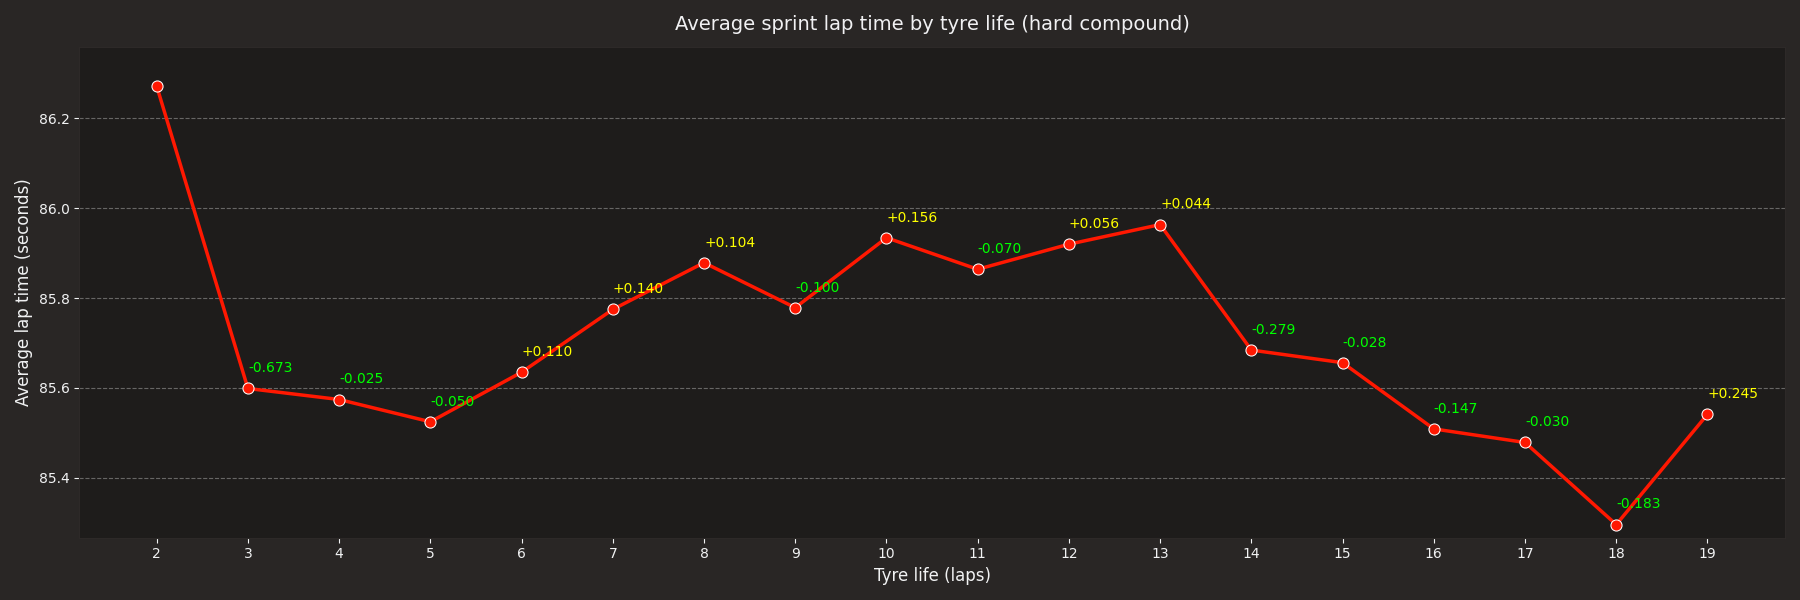

In [36]:
hard_mean_laps_by_life = get_tyre_life_stats(hard, session="Sprint")
plot_average_lap_time_by_tyre_wear(hard_mean_laps_by_life, "Hard", sprint)

While the tyre performance still decays after the 5th lap, the deltas are lower, that is, there is less variation in lap time. Let's calculate the difference between the standard deviation of medium tyres and hard tyres for the overall grid.

In [37]:
decrease_of_std = (
    mean_laps_by_life_medium.LapTime_s.std() - hard_mean_laps_by_life.LapTime_s.std()
)
print(
    f"Hard tyres have a decrease of {decrease_of_std:.3f} in standard deviation",
    "when compared to medium tyres.",
)

Hard tyres have a decrease of 0.315 in standard deviation when compared to medium tyres.


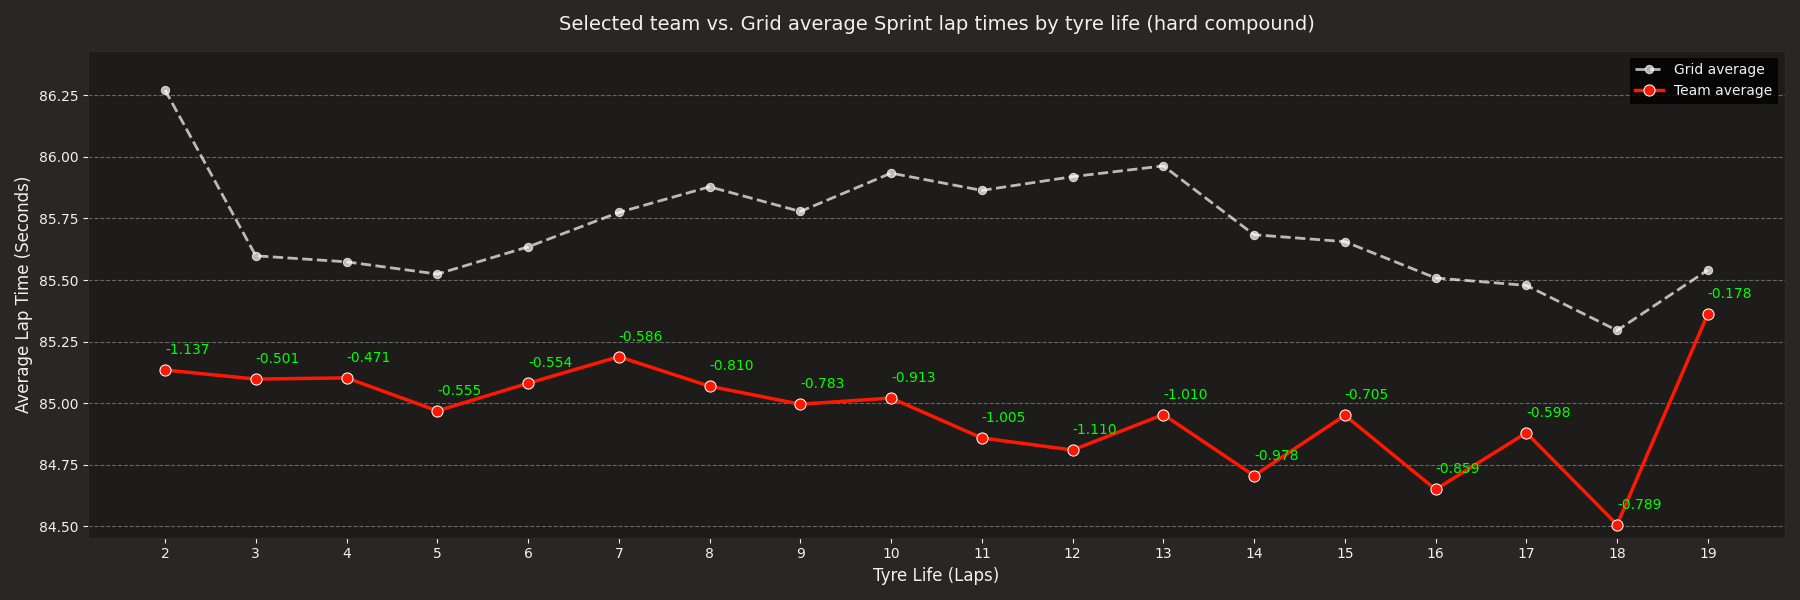

In [ ]:
team_mean_laps_by_life_hard = get_tyre_life_stats(
    hard.pick_teams(TEAM),
    session="Sprint",
)
plot_team_vs_grid_tyre_wear(
    hard_mean_laps_by_life,
    team_mean_laps_by_life_hard,
    "HARD",
    "Sprint",
)

In [39]:
print(
    f"Overall average lap time: {hard_mean_laps_by_life.LapTime_s.mean():.3f} "
    f"+/- {hard_mean_laps_by_life.LapTime_s.std():.3f}",
)

Overall average lap time: 85.716 +/- 0.231


In [40]:
print(
    f"Our team's average lap time: {team_mean_laps_by_life_hard.LapTime_s.mean():.3f} "
    f" +/- {team_mean_laps_by_life_hard.LapTime_s.std():.3f}",
)

Our team's average lap time: 84.963  +/- 0.206


Once again when analyzing our team's performance against the grid, it is possible to see lower average lap time and slightly better consistency. Less dramatic spikes in lap time, and a different trend direction from lap 7 to 12!

In [41]:
mann_whitney_u_test(
    hard_mean_laps_by_life.LapTime_s,
    hard_mean_laps_by_life.LapTime_s,
)
print()
ks_test(team_mean_laps_by_life_hard.LapTime_s, team_mean_laps_by_life_hard.LapTime_s)

========== Mann-Whitney U test ==========
Test statistic 162.0000
P-Value 1.0000
There IS a statistically significant difference between the series.

========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions


(np.float64(0.0), np.float64(1.0))

The tests also return differing results from the medium tyres: there IS a statistically significant difference between the series mean locations, while the distribution seems to be the same.

### 🔴 Analyzing Soft Tyre Compound influence on lap time

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


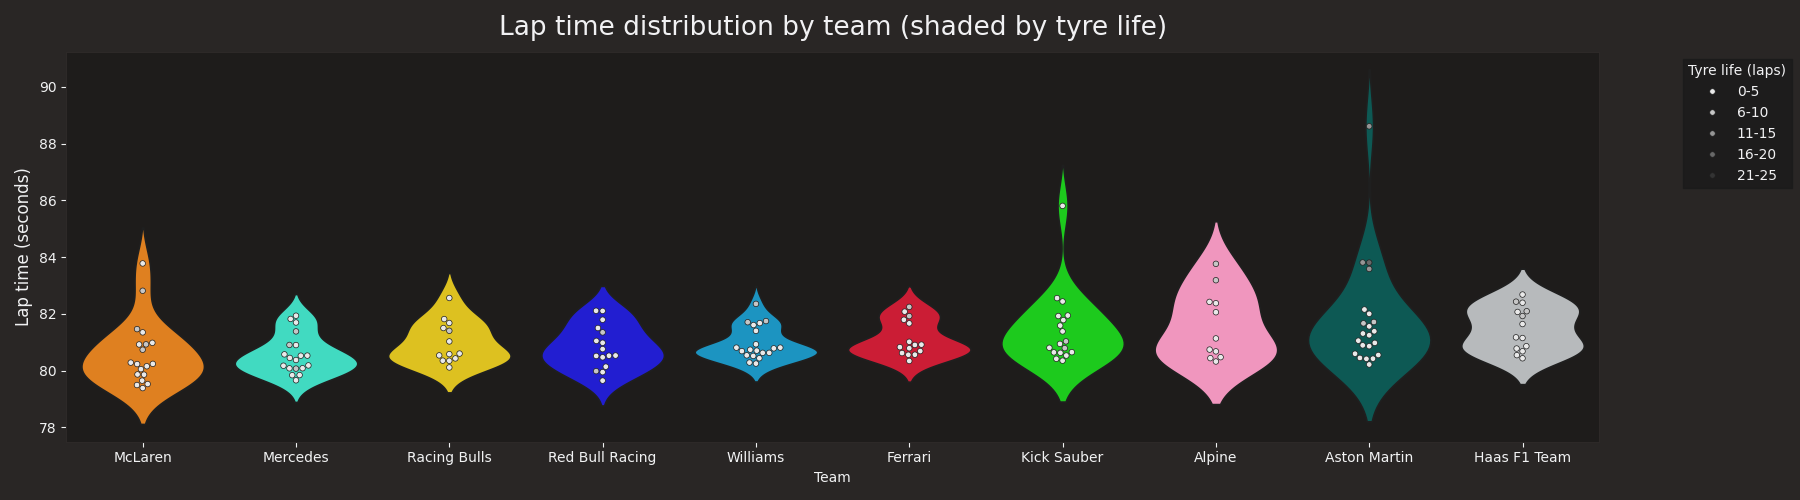

In [43]:
plot_laptime_distribution_by_team_with_tyre_life(soft, quali)

While the graph for hard tyres was concentrated on higher laps with more tyre wear, mediums had both concentrations on lower lap times and higher with more distributed tyre wear, the soft tyres are concentrated on lower tyre wear range, with faster lap times.

Due to the low number of data points using soft tyres, we will skip Mann-Whitney U tests as they may become imprecise.

In [ ]:
compare_team_series_to_overall_series(ks_test, soft, TEAM, "LapTime_s")

Comparing against Red Bull Racing
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Kick Sauber
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Racing Bulls
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Alpine
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Mercedes
========== Kolomogorov-Smirnov test ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NO significant difference in distributions

Comparing against Aston Martin
========== Kolomogorov-Smir

For soft tyres, it was not possible to detect significant differences between the distributions of lap times against other teams.

#### 🔴 How do these tyres influence on lap time?

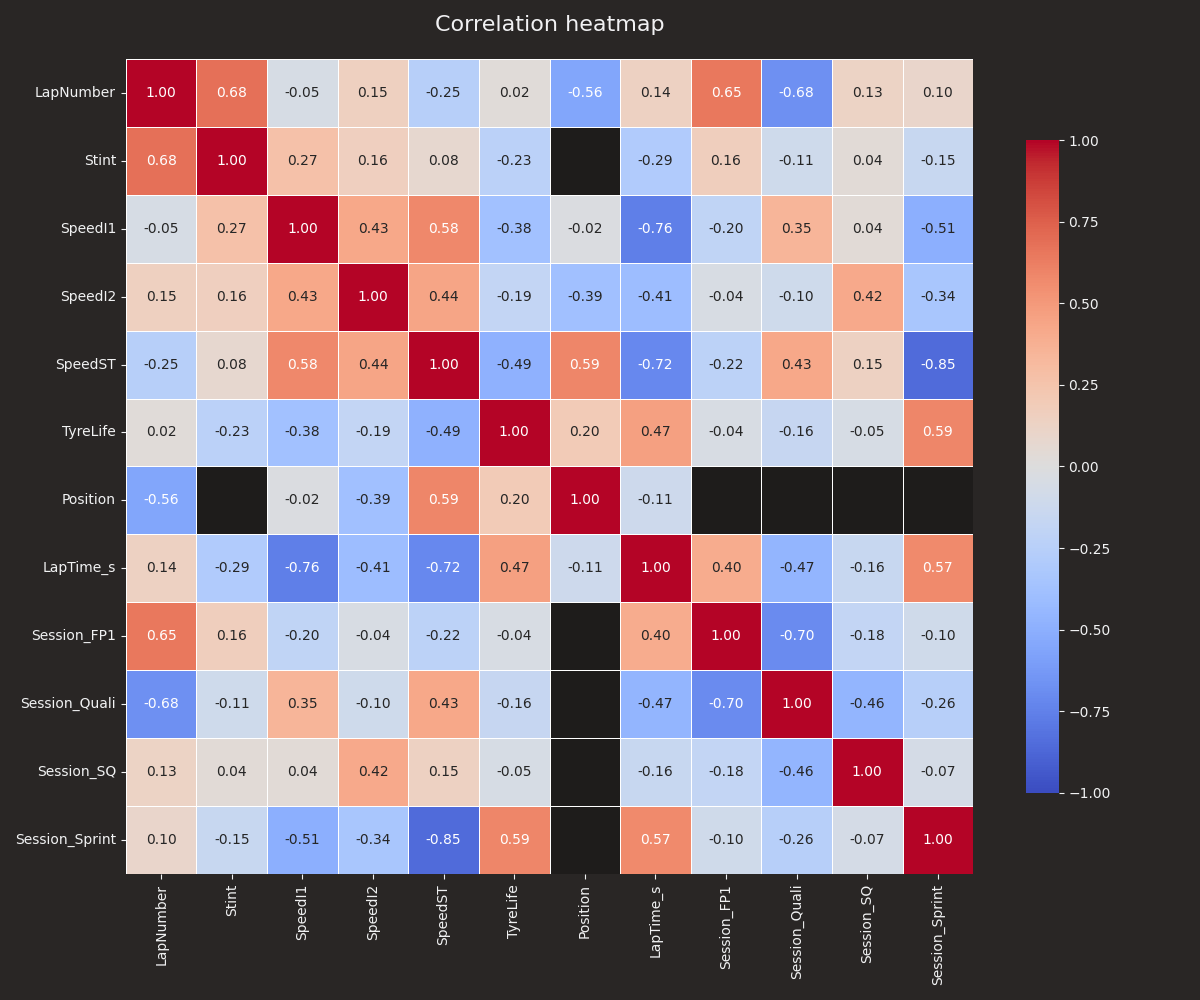


--- Correlations with LapTime_s ---
SpeedI1           -0.76
SpeedST           -0.72
Session_Sprint     0.57
Session_Quali     -0.47
TyreLife           0.47
SpeedI2           -0.41
Session_FP1        0.40
Stint             -0.29
Session_SQ        -0.16
LapNumber          0.14
Position          -0.11
Name: LapTime_s, dtype: object


In [45]:
plot_laptime_correlation_heatmap(soft)

Speed through the first intermediate of the track was once again the most decisive feature to extract good lap times on softs, and almost as decisive is speed on the straights.

There seems to be a moderate negative correlation between tyre wear and both speed measures SpeedI1 (-0.49 for SpeedST and -0.38 for SpeedI1).

There is also a direct correlation between higher tyre life and increase in lap times.

#### 🔴 Soft Tyre Performance Decay

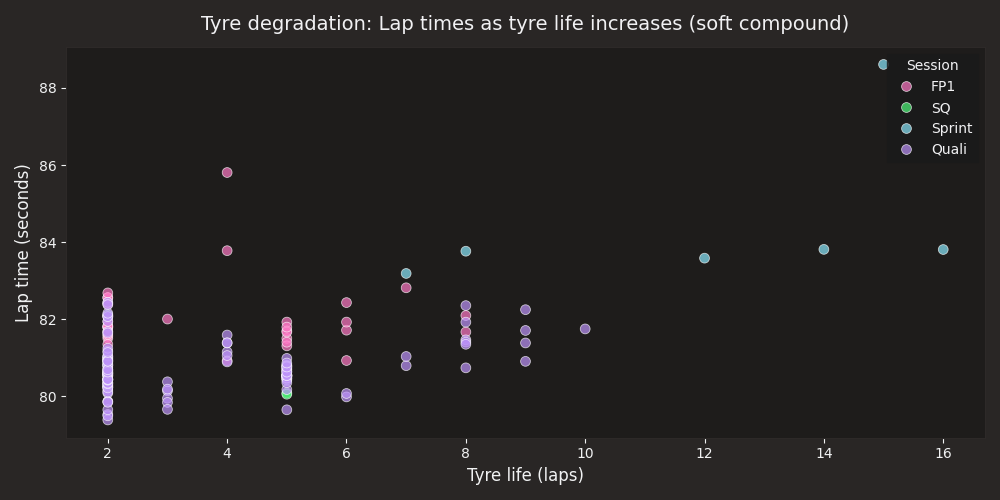

In [46]:
plot_tyre_decay_scatter_plot(soft)

The graph for soft tyres is more spaced out, and times registered from 12 laps already have significant increase in lap times.

Soft tyres were also used in all previous sessions.

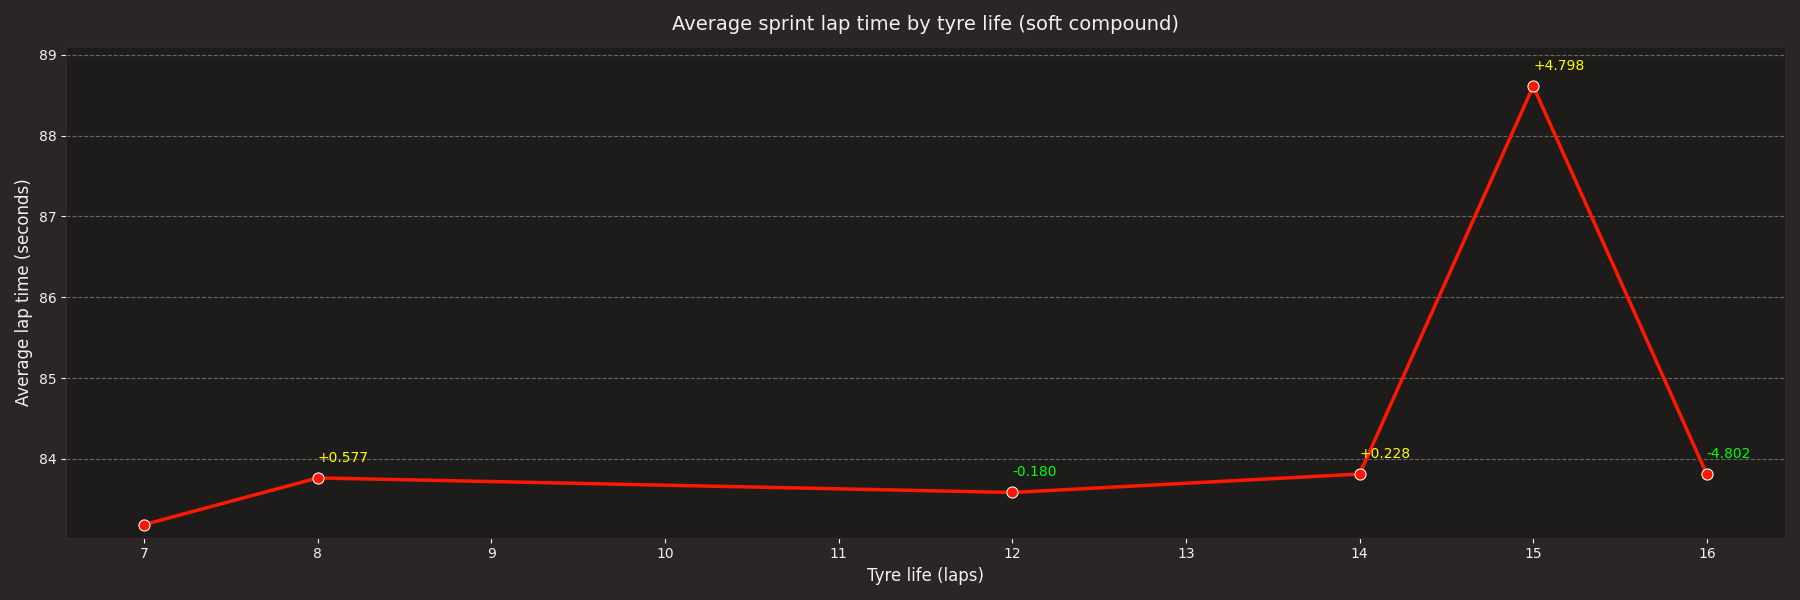

In [47]:
mean_laps_by_life_soft = get_tyre_life_stats(soft, session="Sprint")
plot_average_lap_time_by_tyre_wear(mean_laps_by_life_soft, "Soft", sprint)

This graph displays a lot of variance and big dropoffs in tyre performance, however, as there are only 5 data points for soft tyres in the sprint session, let's include other sessions into the analysis.

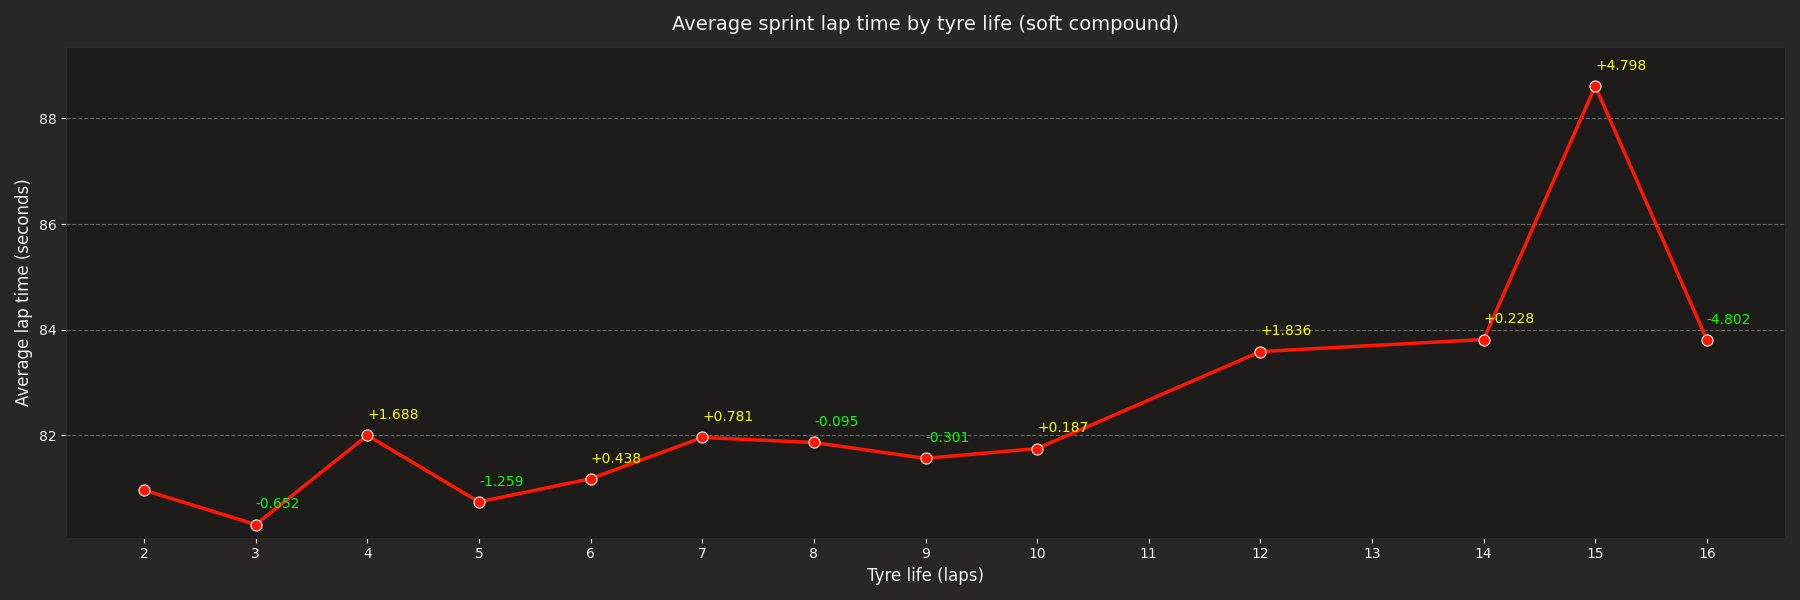

In [48]:
mean_laps_by_life_soft_all_sessions = get_tyre_life_stats(soft)
plot_average_lap_time_by_tyre_wear(mean_laps_by_life_soft_all_sessions, "Soft", sprint)

In [49]:
sprint.session_info["Name"]

'Sprint'

This graph displays high drops in performance, that seems to be aggravated from lap 10. The intervals are way more agressive than the other compounds.

While the standard deviation for other compounds are measured in milisseconds, the deviation for soft tyres are measured in seconds!

In [50]:
print(
    f"Hard: {hard_mean_laps_by_life.LapTime_s.std():.3f}\n"
    f"Medium: {mean_laps_by_life_medium.LapTime_s.std():.3f}\n",
    f"Soft: {mean_laps_by_life_soft_all_sessions.LapTime_s.std():.3f}",
)

Hard: 0.231
Medium: 0.545
 Soft: 2.167


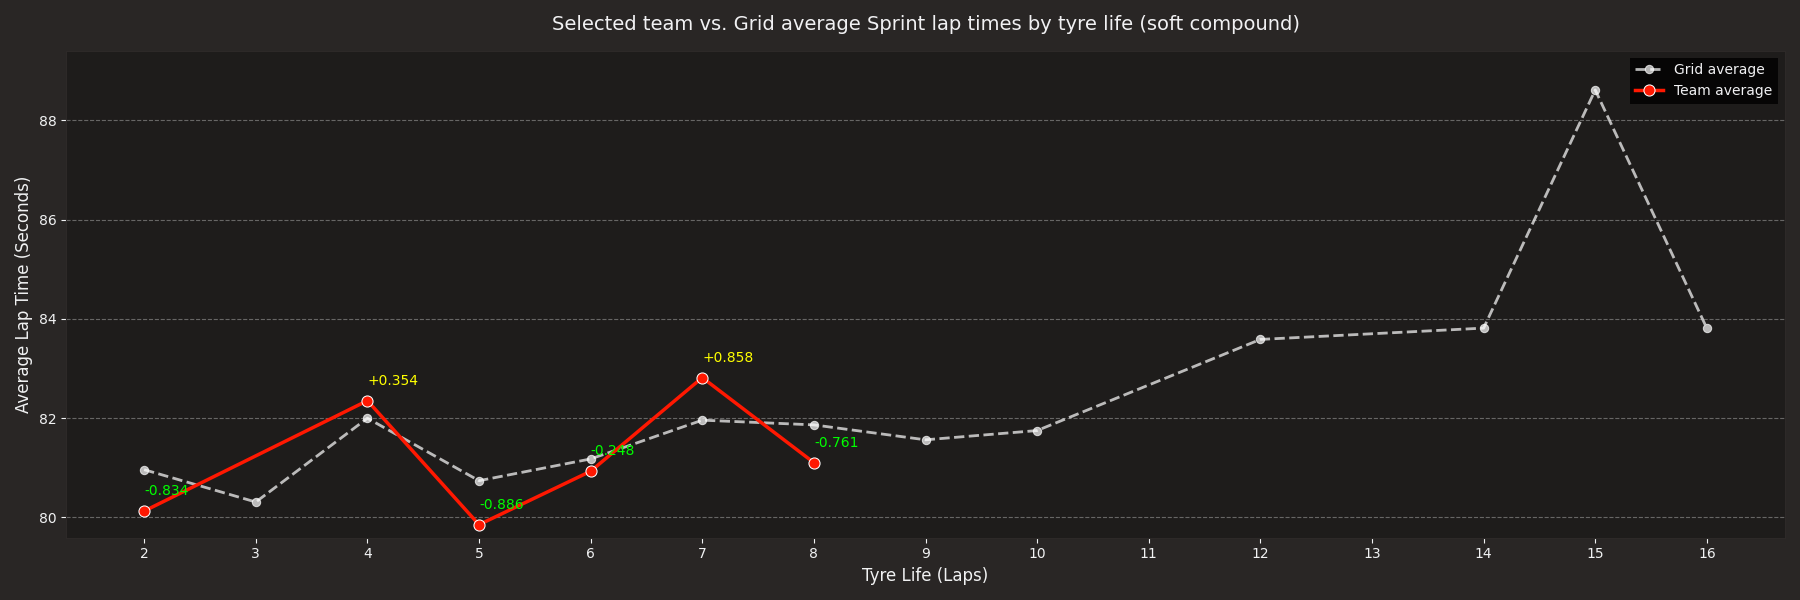

In [ ]:
team_mean_laps_by_life_soft = get_tyre_life_stats(soft.pick_teams(TEAM))
plot_team_vs_grid_tyre_wear(
    mean_laps_by_life_soft_all_sessions,
    team_mean_laps_by_life_soft,
    "SOFT",
    "Sprint",
)

Additionally our team's performance on soft tyres is visually consistent to the other teams, unlike medium and hard compounds.

## 💡 Summary and conclusions

### 🕒 Lap Time Distribution

Lap times across all compounds are not normally distributed according to Shapiro-Wilk hypothesis tests, which is expected behaviour in motorsport where cars operate near physical limits. This means non-parametric statistical tests (Mann-Whitney U and Kolmogorov-Smirnov) had to be used throughout the analysis.

### ⚡️ Speed Metrics

**Speed through Intermediate 1 (SpeedI1)** was identified as the most important on-track metric — significantly correlated with lap time across all compounds. As expected, upon visual inspection, it mirrors the lap time distribution inversely.

### 🛞 Tyre compound analysis

🟡 Medium Tyres
- Optimal performance window: **laps 8–15**.
- Strongest correlations with lap time: session type (−0.93/+0.93), SpeedI1 (−0.92), position (0.81), tyre life (0.63).
- The main statistically significant differentiator between teams on mediums is consistency (distribution shape), not raw pace (median/mean) — most teams have statistically indistinguishable central locations.
- Our team on mediums: average lap 84.75s ± 0.36s vs. grid's 86.17s ± 0.55s — faster and more consistent.

⚪ Hard Tyres
- Optimal performance window: the interval of lap time does not vary much, but the grid trend is of slowly diminishing performance after 5 laps, while our team's trend is of slowly increasing performance up until 14 laps.
- Less tyre life sensitivity: TyreLife correlation is of only 0.05 with lap time.
- SpeedI1 remains important (−0.66).
- Hard tyres show **0.315s less standard deviation** than mediums — more predictable degradation.
- Our team on hards: 84.96s ± 0.21s vs. grid's 85.72s ± 0.23s — **faster and slightly more consistent**, with a notably different (favorable) trend between laps 7–12.

🔴 Soft Tyres
- Concentrated on low tyre life ranges with fast lap times — primarily a qualifying compound.
- Performance degrades sharply from lap 10, with standard deviation of 2.17s (vs. 0.54s for medium and 0.23s for hard) — highly variable, sharp decline in performance.
- Our team's soft tyre performance is similar to the rest of the grid — no meaningful advantage here, unlike on the other two compounds.

### 🏁 Overall strategic insights

1. Intermediate 1 is the circuit's most critical sector — teams should focus setup and driving style on maximizing speed through the first intermediate sector.
2. Medium tyres are the sweet spot: our team has a clear pace and consistency advantage on them, making them the preferred race compound.
3. Hard tyres offer stability for long stints with lower degradation variance, and our team also has an edge on them.
4. Soft tyres should be used sparingly in the race — high degradation variance and no clear advantage make them a risk over longer stints.
5. Consistency over raw pace is the key differentiating factor in lap times — the KS test confirmed that distribution shape (variance) separates teams more than their median lap times.

## 🌱 Future works and improvements